# 🩺 Diabetes Prediction Pipeline
**Dataset:** Pima Indians Diabetes Dataset  
**Target:** `Outcome` — 1 = Diabetes, 0 = Tidak Diabetes  
**Struktur Notebook:**
- **Bagian A** — Exploratory Data Analysis (EDA)
- **Bagian B** — Penanganan Missing Value
- **Bagian C** — Transformasi Data (Normalisasi)
- **Bagian D** — Implementasi Model (Logistic Regression, Random Forest, Gradient Boosting, Stacking)
- **Bagian E** — Evaluasi & Perbandingan Model
- **Bagian F** — Laporan dan Interpretasi Hasil

---
## ⚙️ Setup & Import Library

In [1]:
# === Import Libraries ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score,
    ConfusionMatrixDisplay
)

# Style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Semua library berhasil di-import!")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   sklearn : {__import__('sklearn').__version__}")

✅ Semua library berhasil di-import!
   pandas  : 2.2.3
   numpy   : 2.2.6
   sklearn : 1.6.1


In [2]:
# Load Dataset
df = pd.read_csv('./dataset/diabetes.csv')
print(f"Shape dataset: {df.shape}")
df.head()

Shape dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---
## 📊 BAGIAN A: Exploratory Data Analysis (EDA)

### A.1 — Gambaran Umum Dataset

In [3]:
print("=" * 60)
print("INFO DATASET")
print("=" * 60)
df.info()
print()
print("=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)
df.describe().round(2)

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

STATISTIK DESKRIPTIF


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


### A.2 — Distribusi Target (Class Balance)

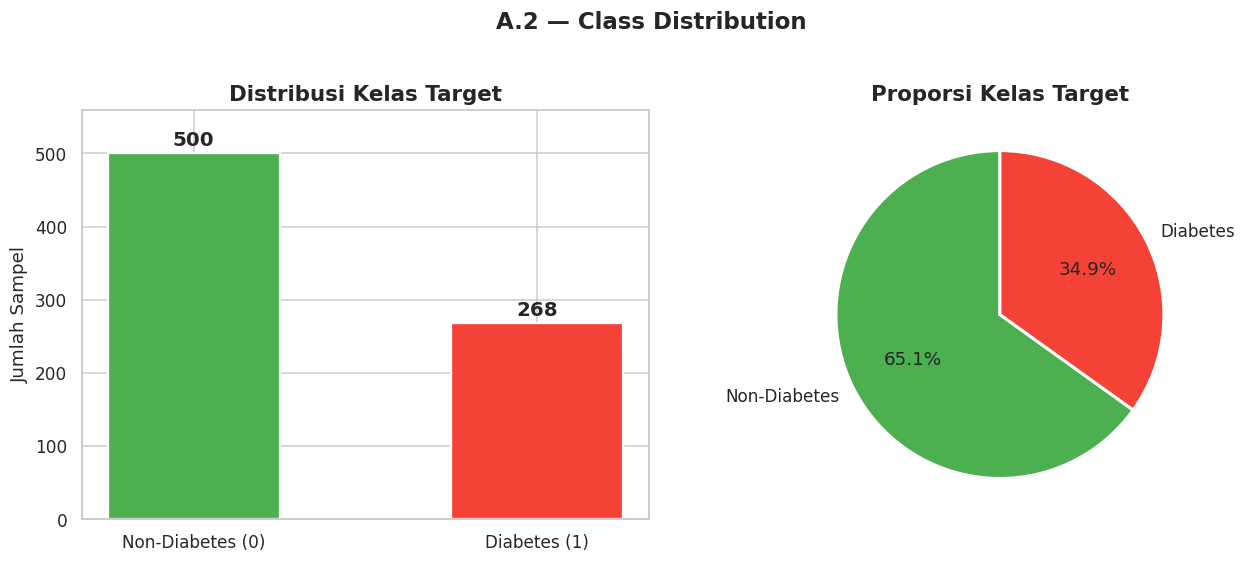

Non-Diabetes : 500 (65.1%)
Diabetes     : 268 (34.9%)
Rasio imbalance: 1.87:1


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['Outcome'].value_counts()
bars = axes[0].bar(['Non-Diabetes (0)', 'Diabetes (1)'], counts.values,
                   color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=13)
axes[0].set_title('Distribusi Kelas Target', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, counts.max() + 60)

# Pie chart
axes[1].pie(counts.values, labels=['Non-Diabetes', 'Diabetes'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Target', fontsize=14, fontweight='bold')

plt.suptitle('A.2 — Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Non-Diabetes : {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"Diabetes     : {counts[1]} ({counts[1]/len(df)*100:.1f}%)")
print(f"Rasio imbalance: {counts[0]/counts[1]:.2f}:1")

### A.3 — Deteksi Zero Values sebagai Pseudo-Missing

Zero Values pada Kolom Medis (= missing value tersembunyi):
               Jumlah Zero  Persentase (%)
Glucose                  5            0.65
BloodPressure           35            4.56
SkinThickness          227           29.56
Insulin                374           48.70
BMI                     11            1.43


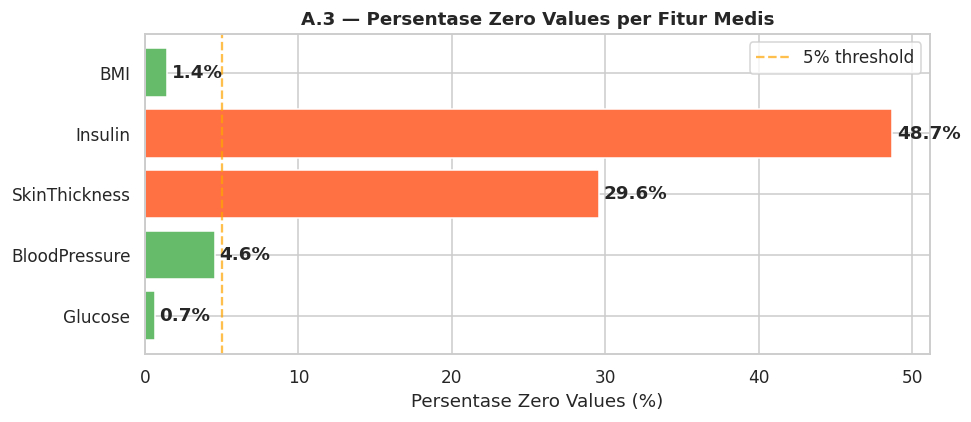

In [5]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_summary = pd.DataFrame({
    'Jumlah Zero': [(df[col] == 0).sum() for col in zero_cols],
    'Persentase (%)': [(df[col] == 0).mean() * 100 for col in zero_cols]
}, index=zero_cols).round(2)

print("Zero Values pada Kolom Medis (= missing value tersembunyi):")
print(zero_summary.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#FF7043' if v > 10 else '#FFA726' if v > 5 else '#66BB6A'
          for v in zero_summary['Persentase (%)']]
bars = ax.barh(zero_cols, zero_summary['Persentase (%)'], color=colors, edgecolor='white')
for bar, val in zip(bars, zero_summary['Persentase (%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')
ax.set_xlabel('Persentase Zero Values (%)')
ax.set_title('A.3 — Persentase Zero Values per Fitur Medis', fontweight='bold')
ax.axvline(5, color='orange', linestyle='--', alpha=0.7, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

### A.4 — Distribusi Setiap Fitur

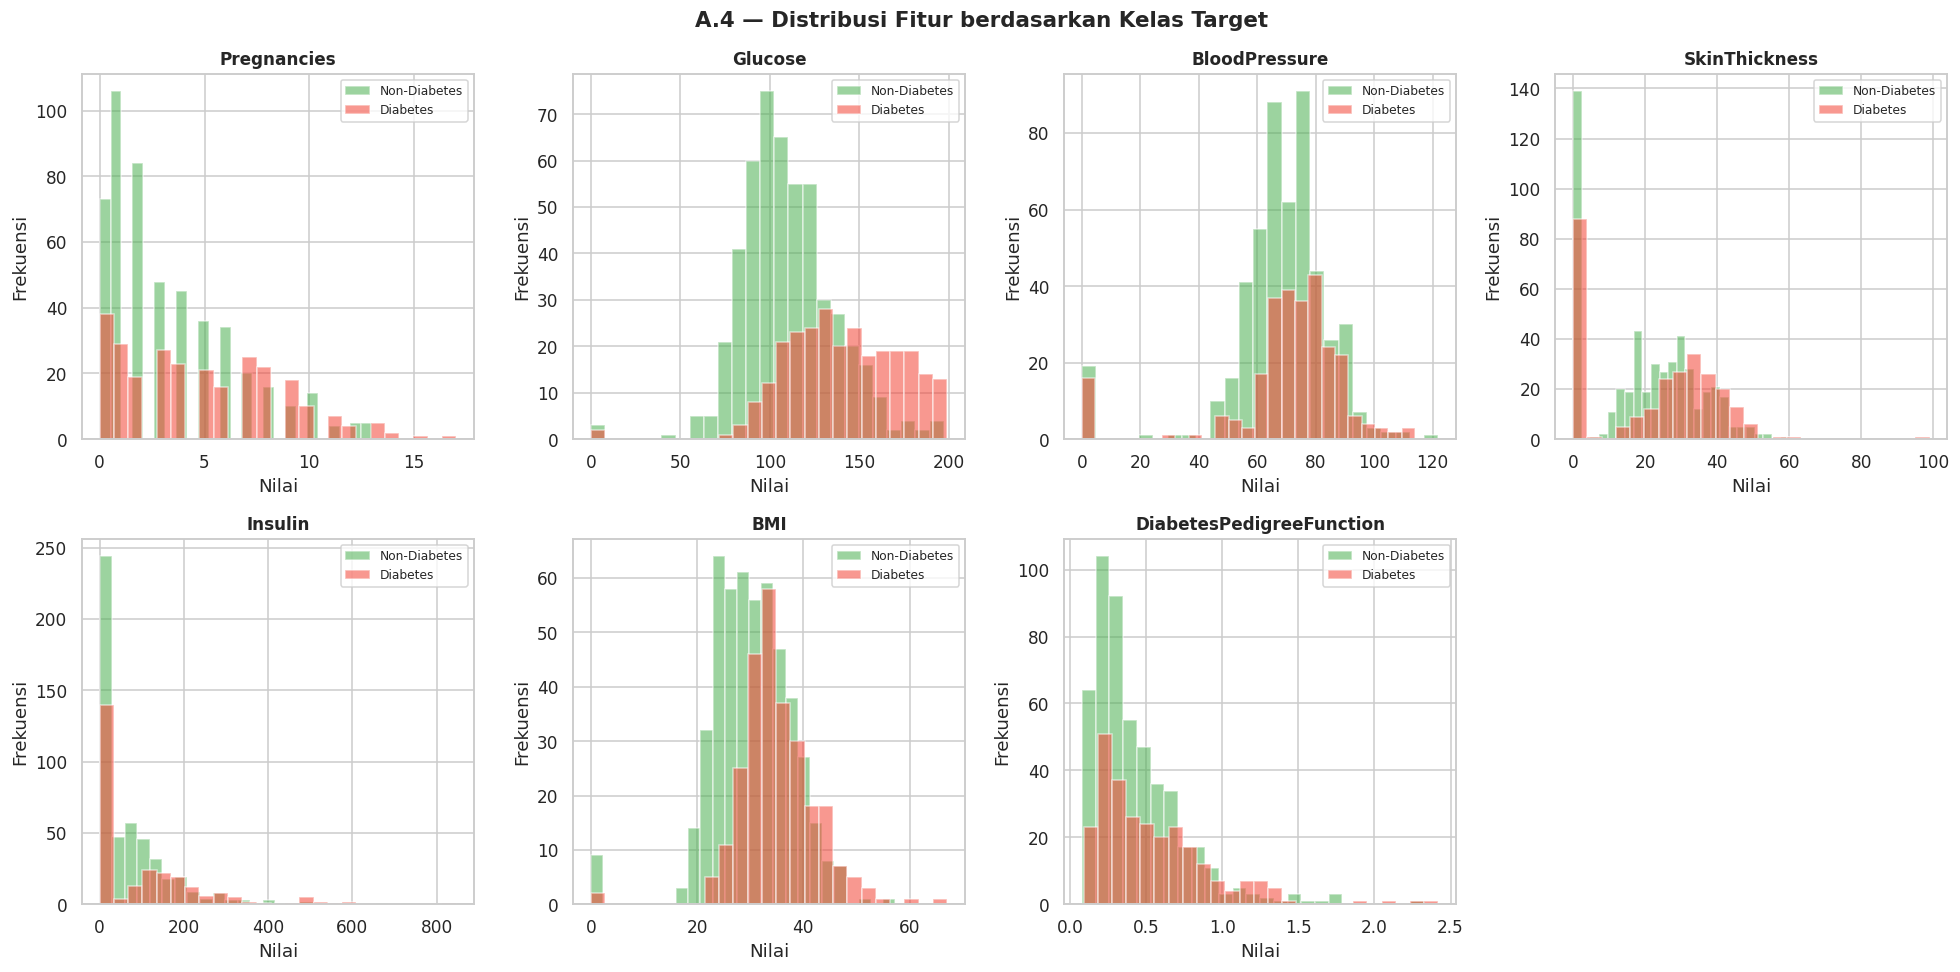

In [6]:
features = [c for c in df.columns if c != 'Outcome']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    for outcome, color, label in zip([0, 1], ['#4CAF50', '#F44336'],
                                     ['Non-Diabetes', 'Diabetes']):
        subset = df[df['Outcome'] == outcome][col]
        axes[i].hist(subset, bins=25, alpha=0.55, color=color, label=label, edgecolor='white')
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('A.4 — Distribusi Fitur berdasarkan Kelas Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### A.5 — Correlation Heatmap

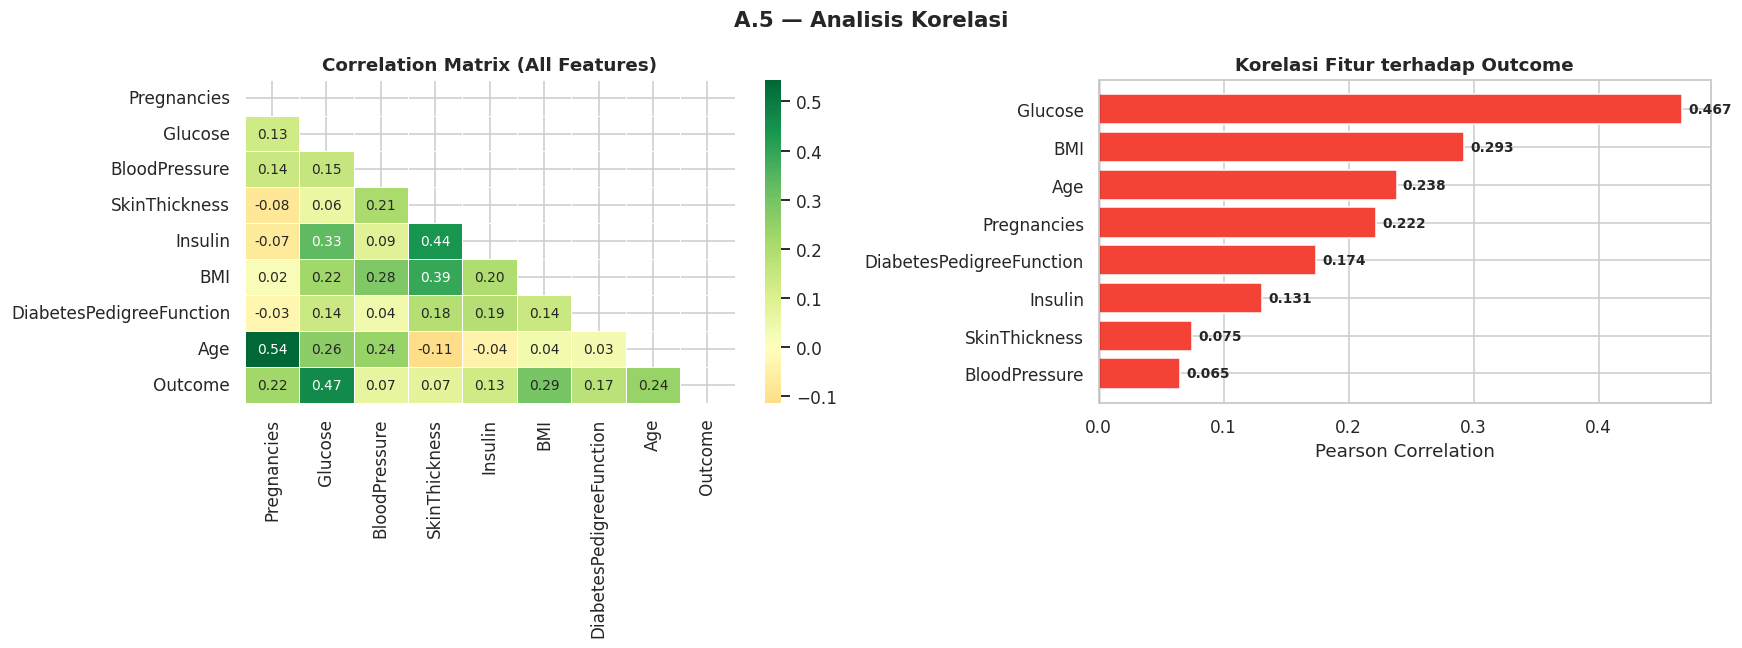

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], linewidths=0.5,
            annot_kws={'size': 9})
axes[0].set_title('Correlation Matrix (All Features)', fontweight='bold')

# Correlation with target only
target_corr = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=True)
colors = ['#F44336' if v > 0 else '#4CAF50' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(target_corr.values):
    axes[1].text(v + (0.005 if v >= 0 else -0.005), i,
                 f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right',
                 fontsize=9, fontweight='bold')
axes[1].set_title('Korelasi Fitur terhadap Outcome', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')

plt.suptitle('A.5 — Analisis Korelasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### A.6 — Boxplot: Perbandingan Fitur per Kelas

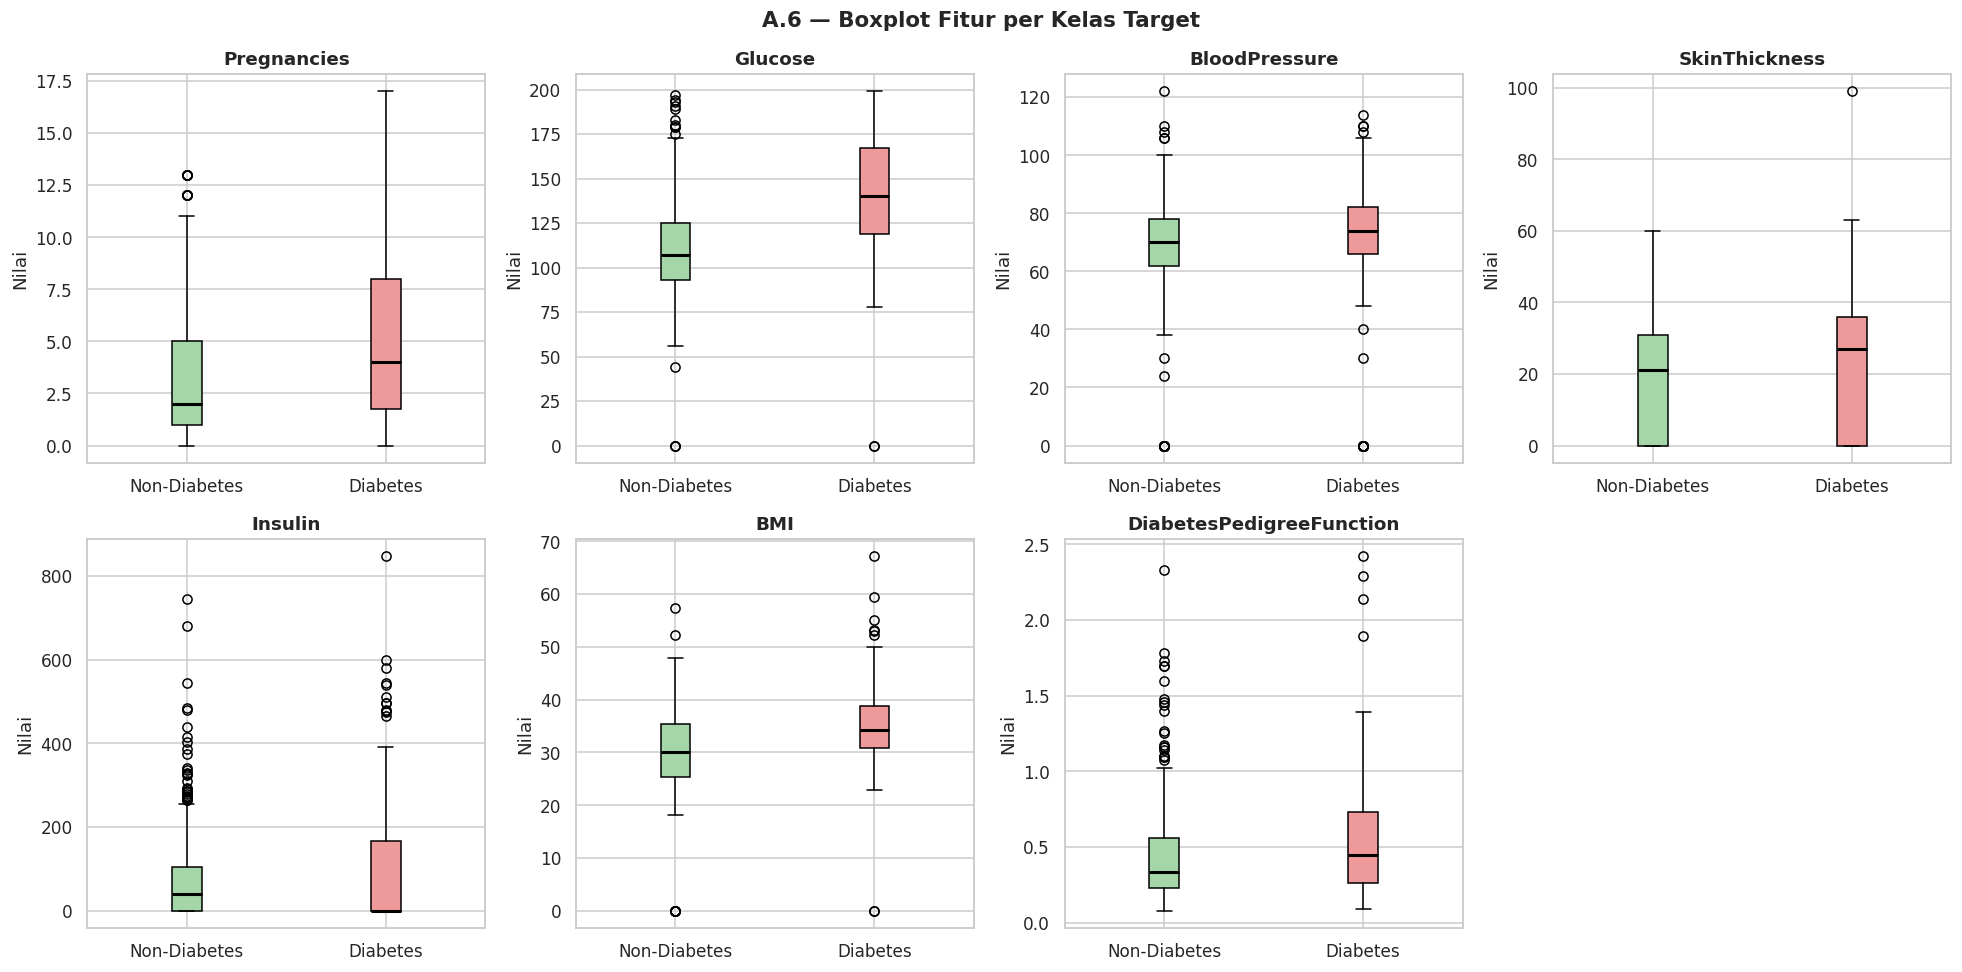

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    data_0 = df[df['Outcome'] == 0][col]
    data_1 = df[df['Outcome'] == 1][col]
    bp = axes[i].boxplot([data_0, data_1],
                         labels=['Non-Diabetes', 'Diabetes'],
                         patch_artist=True,
                         medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#A5D6A7')
    bp['boxes'][1].set_facecolor('#EF9A9A')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Nilai')

axes[-1].set_visible(False)
plt.suptitle('A.6 — Boxplot Fitur per Kelas Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### A.7 — Pair Plot Fitur Paling Korelasi

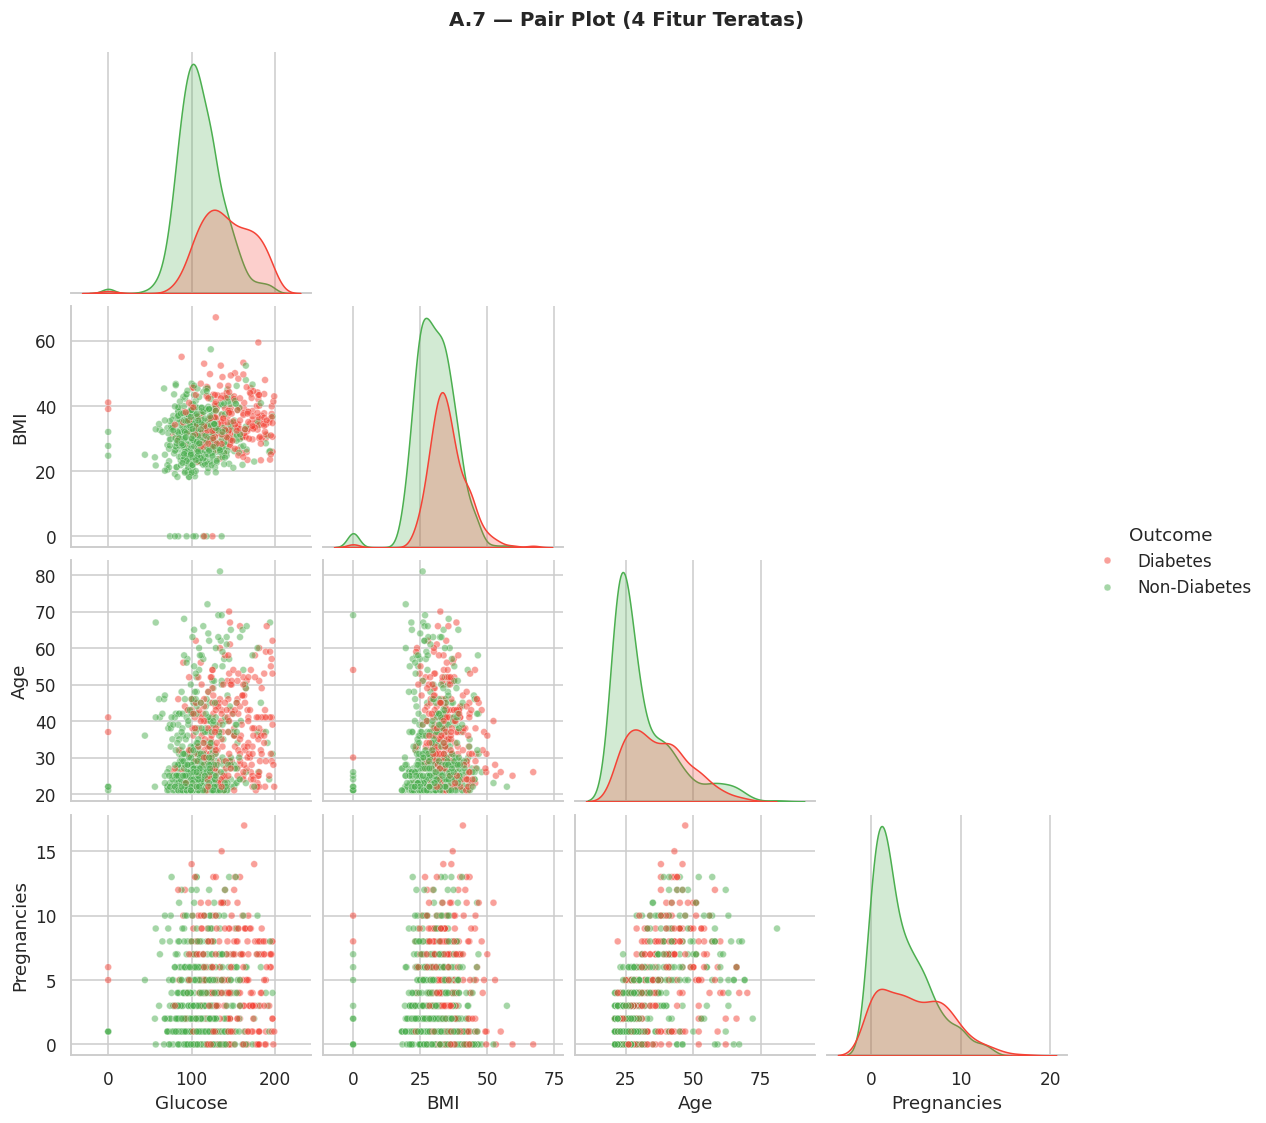

In [9]:
top_features = target_corr.abs().nlargest(4).index.tolist() + ['Outcome']
pair_df = df[top_features].copy()
pair_df['Outcome'] = pair_df['Outcome'].map({0: 'Non-Diabetes', 1: 'Diabetes'})

g = sns.pairplot(pair_df, hue='Outcome', corner=True,
                 palette={'Non-Diabetes': '#4CAF50', 'Diabetes': '#F44336'},
                 plot_kws={'alpha': 0.5, 's': 20},
                 diag_kind='kde')
g.fig.suptitle('A.7 — Pair Plot (4 Fitur Teratas)', y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## 🔧 BAGIAN B: Implementasi Penanganan Missing Value

### B.1 — Identifikasi & Tandai Zero sebagai NaN

Missing Values setelah konversi zero → NaN:
               Jumlah NaN  Persentase (%)
Glucose                 5            0.65
BloodPressure          35            4.56
SkinThickness         227           29.56
Insulin               374           48.70
BMI                    11            1.43


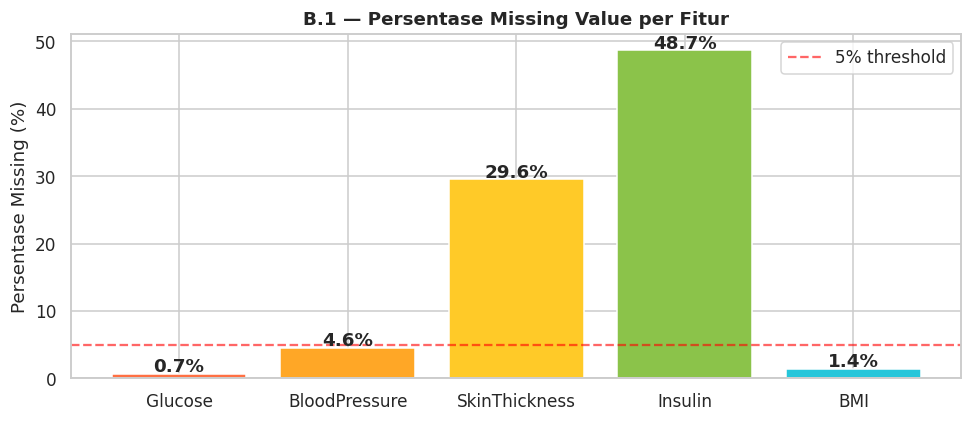

In [10]:
df_clean = df.copy()

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)

missing = df_clean.isnull().sum()
missing_pct = (df_clean.isnull().mean() * 100).round(2)

miss_df = pd.DataFrame({'Jumlah NaN': missing, 'Persentase (%)': missing_pct})
miss_df = miss_df[miss_df['Jumlah NaN'] > 0]

print("Missing Values setelah konversi zero → NaN:")
print(miss_df.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(miss_df.index, miss_df['Persentase (%)'],
              color=['#FF7043', '#FFA726', '#FFCA28', '#8BC34A', '#26C6DA'],
              edgecolor='white')
for bar, val in zip(bars, miss_df['Persentase (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('Persentase Missing (%)')
ax.set_title('B.1 — Persentase Missing Value per Fitur', fontweight='bold')
ax.axhline(y=5, color='red', linestyle='--', alpha=0.6, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

### B.2 — Strategi Imputasi Berdasarkan Kelas Target

✅ Imputasi selesai menggunakan Class-Conditional Median
   Missing Values tersisa: 0


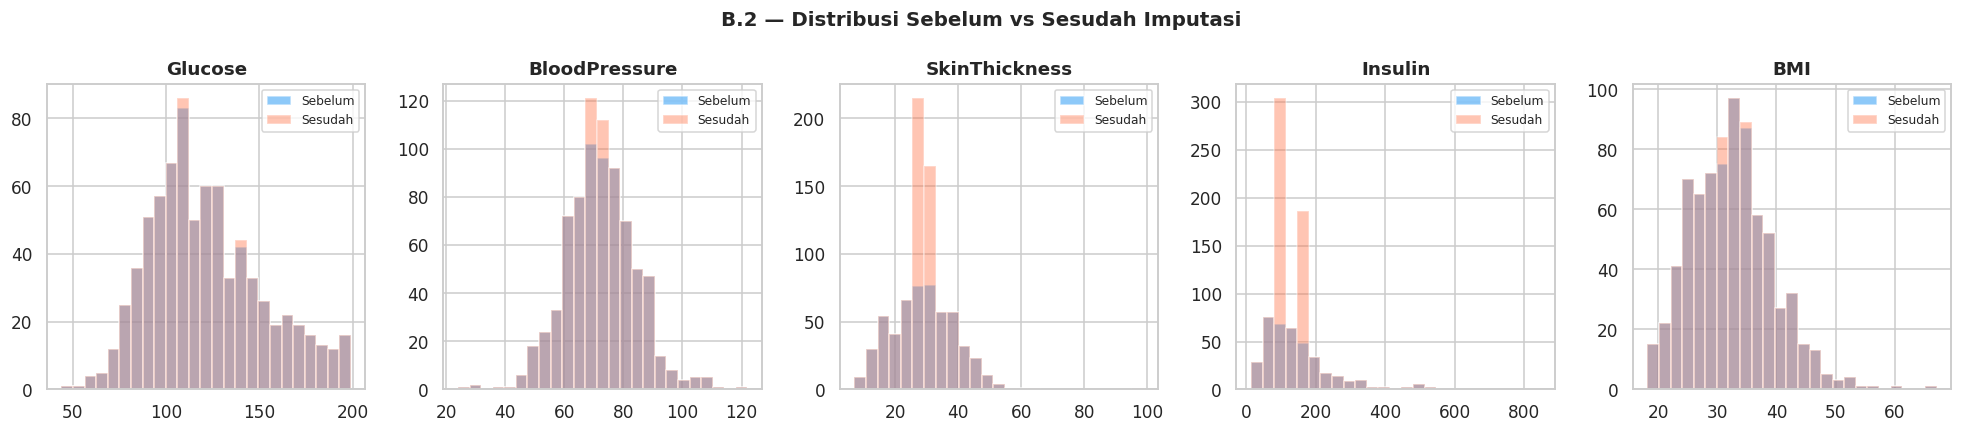

In [11]:
df_imputed = df_clean.copy()

for col in zero_cols:
    for outcome in [0, 1]:
        median_val = df_imputed.loc[df_imputed['Outcome'] == outcome, col].median()
        df_imputed.loc[
            (df_imputed['Outcome'] == outcome) & (df_imputed[col].isnull()), col
        ] = median_val
        
print("✅ Imputasi selesai menggunakan Class-Conditional Median")
print(f"   Missing Values tersisa: {df_imputed.isnull().sum().sum()}")

fig, axes = plt.subplots(1, len(zero_cols), figsize=(18, 4))
for i, col in enumerate(zero_cols):
    axes[i].hist(df_clean[col].dropna(), bins=25, alpha=0.6, label='Sebelum', color='#42A5F5')
    axes[i].hist(df_imputed[col], bins=25, alpha=0.4, label='Sesudah', color='#FF7043')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
plt.suptitle('B.2 — Distribusi Sebelum vs Sesudah Imputasi', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### B.3 — Deteksi & Penanganan Outlier (IQR Method)

In [12]:
df_no_outlier = df_imputed.copy()

outlier_info = {}
for col in features:
    Q1 = df_no_outlier[col].quantile(0.25)
    Q3 = df_no_outlier[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_no_outlier[col] < lower) | (df_no_outlier[col] > upper)).sum()
    outlier_info[col] = {'Lower': round(lower, 2), 'Upper': round(upper, 2), 'Outliers': n_out}
    df_no_outlier[col] = df_no_outlier[col].clip(lower=lower, upper=upper)

out_df = pd.DataFrame(outlier_info).T
print("Ringkasan Outlier (IQR Method) dan hasil Winsorizing:")
print(out_df.to_string())
print(f"\n✅ Outlier di-clip (winsorized), shape tetap: {df_no_outlier.shape}")

Ringkasan Outlier (IQR Method) dan hasil Winsorizing:
                          Lower   Upper  Outliers
Pregnancies               -6.50   13.50       4.0
Glucose                   39.00  201.00       0.0
BloodPressure             40.00  104.00      14.0
SkinThickness             14.50   42.50      87.0
Insulin                    2.00  270.00      51.0
BMI                       13.85   50.25       8.0
DiabetesPedigreeFunction  -0.33    1.20      29.0
Age                       -1.50   66.50       9.0

✅ Outlier di-clip (winsorized), shape tetap: (768, 9)


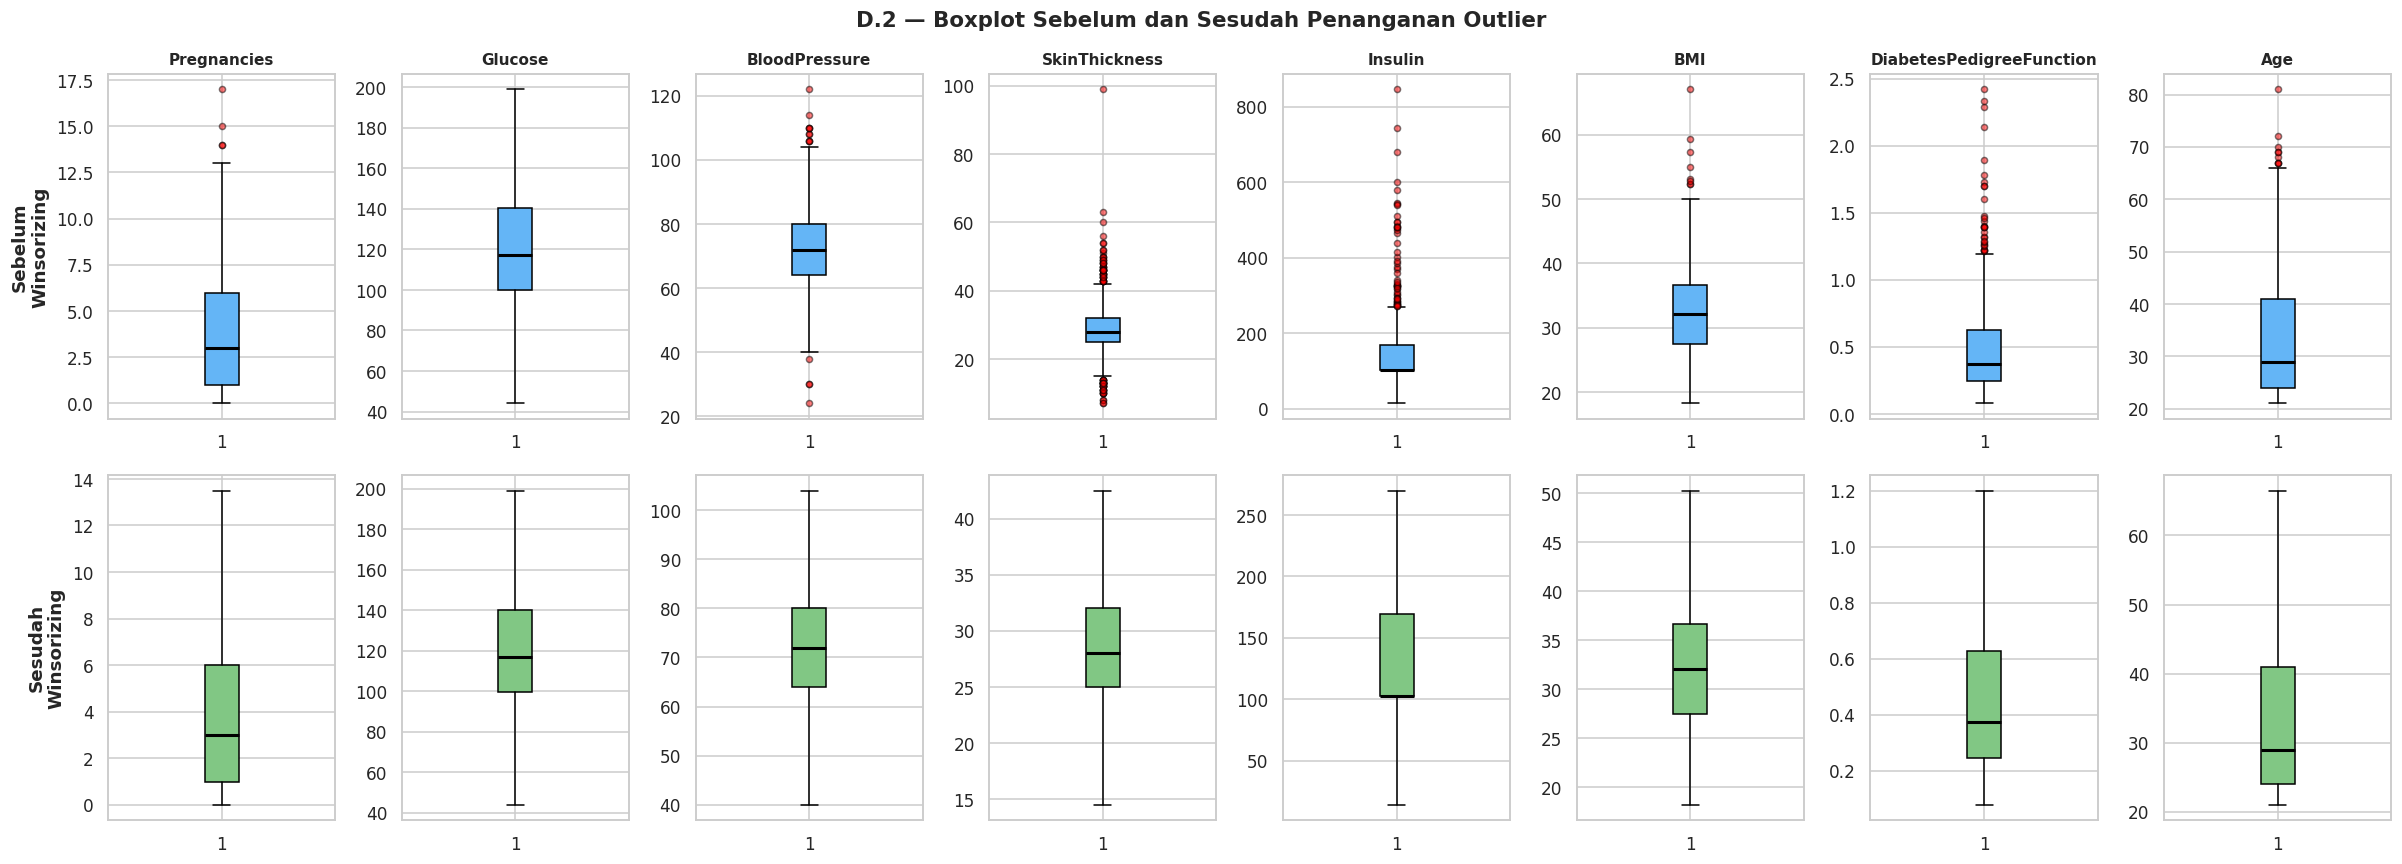

In [ ]:
fig, axes = plt.subplots(2, len(features), figsize=(22, 8))

for i, col in enumerate(features):
    # Sebelum winsorizing
    axes[0, i].boxplot(
        df_imputed[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor='#64B5F6'),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=4, markerfacecolor='red', alpha=0.5)
    )
    axes[0, i].set_title(col, fontweight='bold', fontsize=10)
    if i == 0:
        axes[0, i].set_ylabel('Sebelum\nWinsorizing', fontweight='bold')

    # Sesudah winsorizing
    axes[1, i].boxplot(
        df_no_outlier[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor='#81C784'),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=4, markerfacecolor='red', alpha=0.5)
    )
    if i == 0:
        axes[1, i].set_ylabel('Sesudah\nWinsorizing', fontweight='bold')

plt.suptitle('D.2 — Boxplot Sebelum dan Sesudah Penanganan Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚖️ BAGIAN C: Implementasi Transformasi Data (Normalisasi)

### C.1 — Split Data Sebelum Transformasi

In [14]:
X = df_no_outlier.drop('Outcome', axis=1)
y = df_no_outlier['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total data     : {len(X)} baris")
print(f"Training set   : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set       : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDistribusi target (train): {y_train.value_counts().to_dict()}")
print(f"Distribusi target (test) : {y_test.value_counts().to_dict()}")

Total data     : 768 baris
Training set   : 614 baris (79.9%)
Test set       : 154 baris (20.1%)

Distribusi target (train): {0: 400, 1: 214}
Distribusi target (test) : {0: 100, 1: 54}


### C.2 — StandardScaler (Z-score Normalization)

In [15]:
# Fit scaler HANYA pada training data, transform keduanya
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("Statistik setelah StandardScaler (training set):")
print(X_train_scaled.describe().round(4).loc[['mean', 'std']].to_string())

Statistik setelah StandardScaler (training set):
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  DiabetesPedigreeFunction     Age
mean      -0.0000  -0.0000        -0.0000        -0.0000  -0.0000  0.0000                    0.0000  0.0000
std        1.0008   1.0008         1.0008         1.0008   1.0008  1.0008                    1.0008  1.0008


### C.3 — Perbandingan Distribusi Sebelum vs Sesudah Scaling

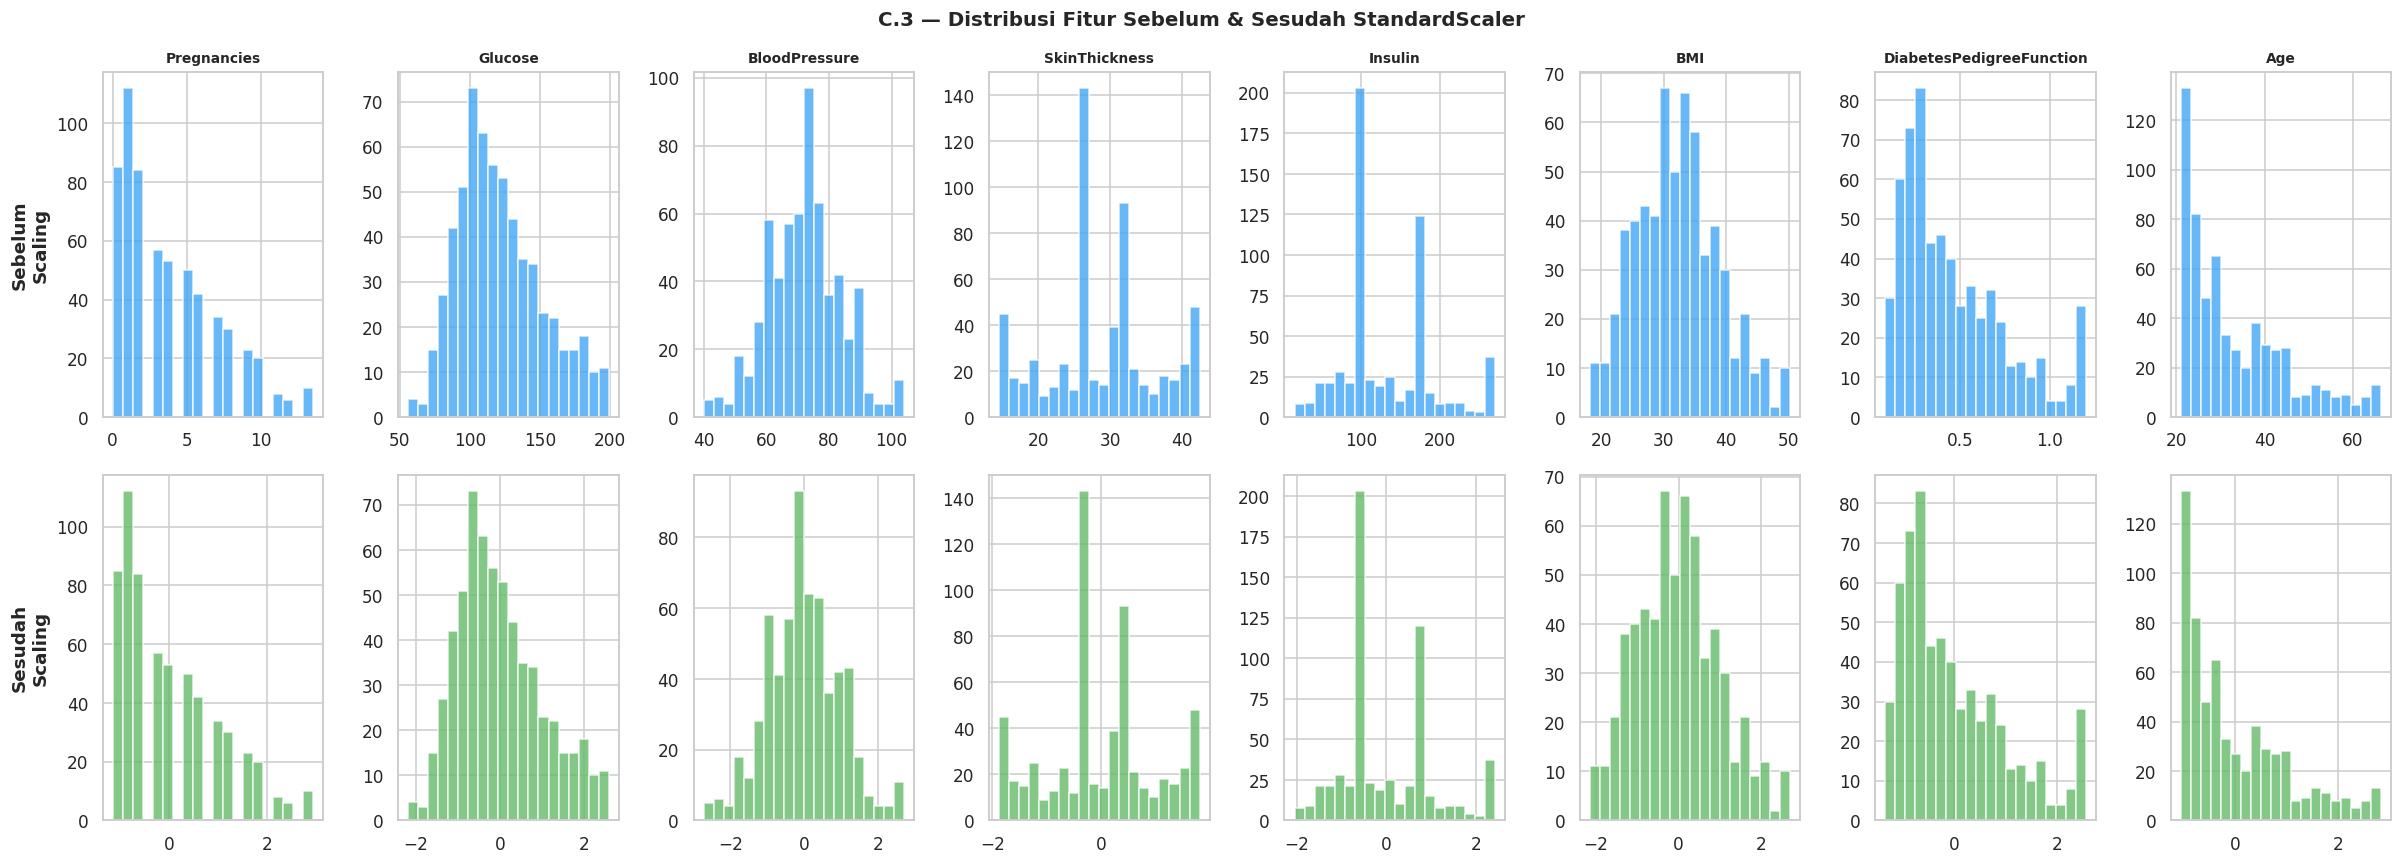

In [16]:
fig, axes = plt.subplots(2, len(features), figsize=(22, 8))

for i, col in enumerate(features):
    axes[0, i].hist(X_train[col], bins=20, color='#42A5F5', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(col, fontweight='bold', fontsize=9)
    if i == 0: axes[0, i].set_ylabel('Sebelum\nScaling', fontweight='bold')

    axes[1, i].hist(X_train_scaled[col], bins=20, color='#66BB6A', edgecolor='white', alpha=0.8)
    if i == 0: axes[1, i].set_ylabel('Sesudah\nScaling', fontweight='bold')

plt.suptitle('C.3 — Distribusi Fitur Sebelum & Sesudah StandardScaler', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 🤖 BAGIAN D: Implementasi Model Machine Learning

### D.1 — Definisi Model Base

In [17]:
base_models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=7, min_samples_split=5,
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8,
        random_state=42
    ),
    'SVM': SVC(
        C=1.0, kernel='rbf', probability=True, random_state=42
    )
}

print("Model yang akan dilatih:")
for name in base_models:
    print(f"  ✓ {name}")

Model yang akan dilatih:
  ✓ Logistic Regression
  ✓ Random Forest
  ✓ Gradient Boosting
  ✓ SVM


### D.2 — Training & Cross-Validation (5-Fold Stratified)

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("=" * 55)
print(f"{'Model':<25} {'CV Accuracy':>15} {'CV AUC':>12}")
print("=" * 55)

for name, model in base_models.items():
    acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    auc_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = {'acc': acc_scores, 'auc': auc_scores}
    print(f"{name:<25} {acc_scores.mean():.4f} ± {acc_scores.std():.3f}  "
          f"{auc_scores.mean():.4f} ± {auc_scores.std():.3f}")

print("=" * 55)

Model                         CV Accuracy       CV AUC
Logistic Regression       0.8193 ± 0.028  0.8862 ± 0.008
Random Forest             0.8827 ± 0.018  0.9436 ± 0.008
Gradient Boosting         0.8778 ± 0.025  0.9462 ± 0.011
SVM                       0.8649 ± 0.015  0.9120 ± 0.015


### D.3 — Visualisasi CV Scores

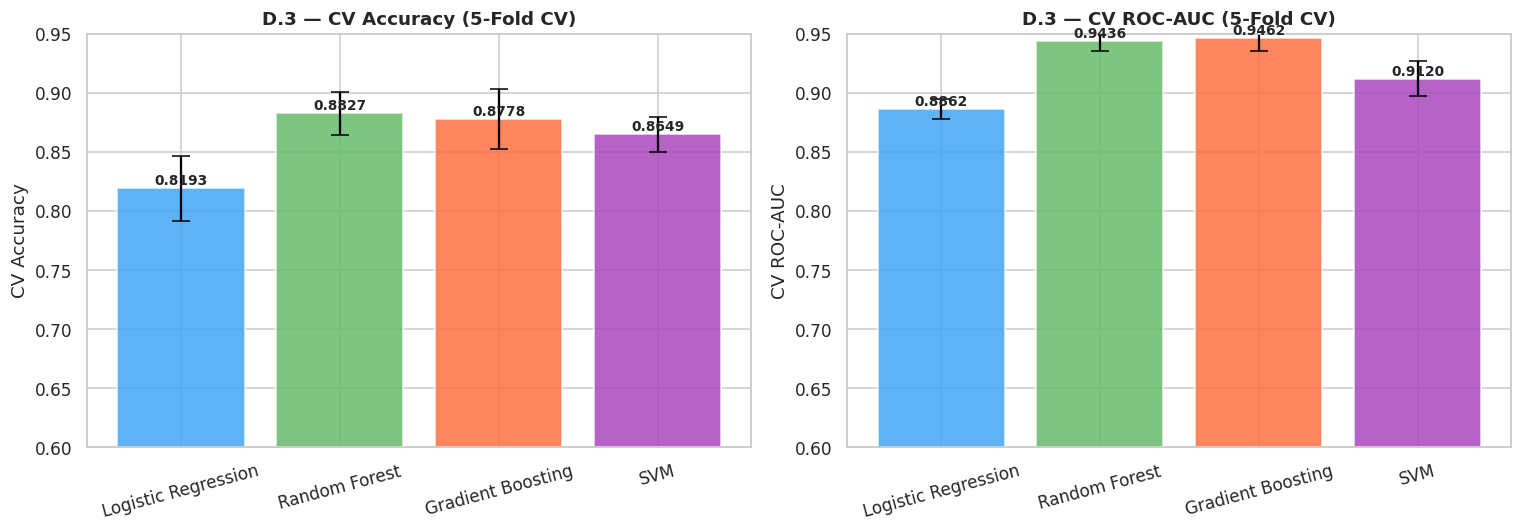

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(cv_results.keys())
colors = ['#42A5F5', '#66BB6A', '#FF7043', '#AB47BC']

for metric_key, ax, title in [('acc', axes[0], 'CV Accuracy'), ('auc', axes[1], 'CV ROC-AUC')]:
    means = [cv_results[m][metric_key].mean() for m in model_names]
    stds  = [cv_results[m][metric_key].std()  for m in model_names]
    bars = ax.bar(model_names, means, yerr=stds, capsize=6,
                  color=colors, edgecolor='white', alpha=0.85)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{mean:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_ylim(0.6, 0.95)
    ax.set_title(f'D.3 — {title} (5-Fold CV)', fontweight='bold')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### D.4 — Stacking Ensemble

In [20]:
estimators = [
    ('lr',  LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42, n_jobs=-1)),
    ('xgb', GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                           subsample=0.8,
                           random_state=42)),
    ('svm', SVC(C=1.0, kernel='rbf', probability=True, random_state=42))
]

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(C=0.5, max_iter=500, random_state=42),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)

stack_acc = cross_val_score(stacking_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
stack_auc = cross_val_score(stacking_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print("Stacking Ensemble — Cross-Validation Results:")
print(f"  Accuracy  : {stack_acc.mean():.4f} ± {stack_acc.std():.4f}")
print(f"  ROC-AUC   : {stack_auc.mean():.4f} ± {stack_auc.std():.4f}")

Stacking Ensemble — Cross-Validation Results:
  Accuracy  : 0.8860 ± 0.0174
  ROC-AUC   : 0.9414 ± 0.0091


---
## 📈 BAGIAN E: Evaluasi & Perbandingan Model

### E.1 — Evaluasi pada Test Set

In [21]:
all_models = dict(base_models) 
all_models['Stacking Ensemble'] = stacking_model

results = {}
print("=" * 75)
print(f"{'Model':<25} {'Accuracy':>10} {'F1-Score':>10} {'ROC-AUC':>10} {'Precision':>10} {'Recall':>10}")
print("=" * 75)

for name, model in all_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_prob  = model.predict_proba(X_test_scaled)[:, 1]
    
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    rep  = classification_report(y_test, y_pred, output_dict=True)
    prec = rep['1']['precision']
    rec  = rep['1']['recall']
    
    results[name] = {
        'accuracy': acc, 'f1': f1, 'auc': auc,
        'precision': prec, 'recall': rec,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    print(f"{name:<25} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f} {prec:>10.4f} {rec:>10.4f}")

print("=" * 75)

Model                       Accuracy   F1-Score    ROC-AUC  Precision     Recall
Logistic Regression           0.7532     0.6481     0.8398     0.6481     0.6481
Random Forest                 0.8636     0.8037     0.9443     0.8113     0.7963
Gradient Boosting             0.8896     0.8411     0.9567     0.8491     0.8333
SVM                           0.8442     0.7778     0.9115     0.7778     0.7778
Stacking Ensemble             0.8831     0.8333     0.9463     0.8333     0.8333


### E.2 — Confusion Matrix Semua Model

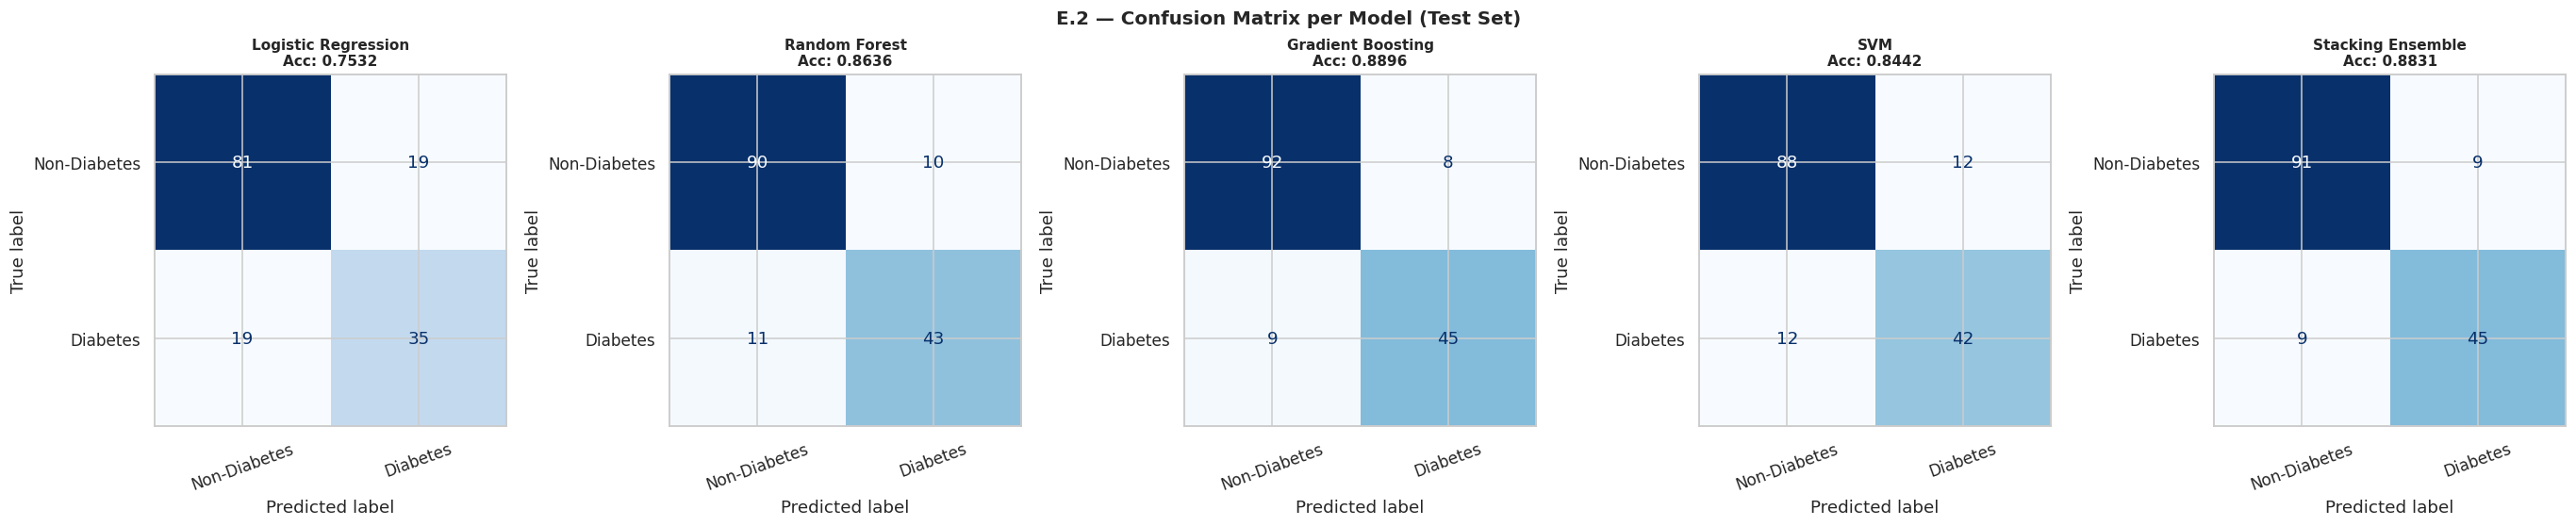

In [22]:
n_models = len(all_models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Diabetes', 'Diabetes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc: {res['accuracy']:.4f}", fontweight='bold', fontsize=10)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('E.2 — Confusion Matrix per Model (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### E.3 — ROC Curve Comparison

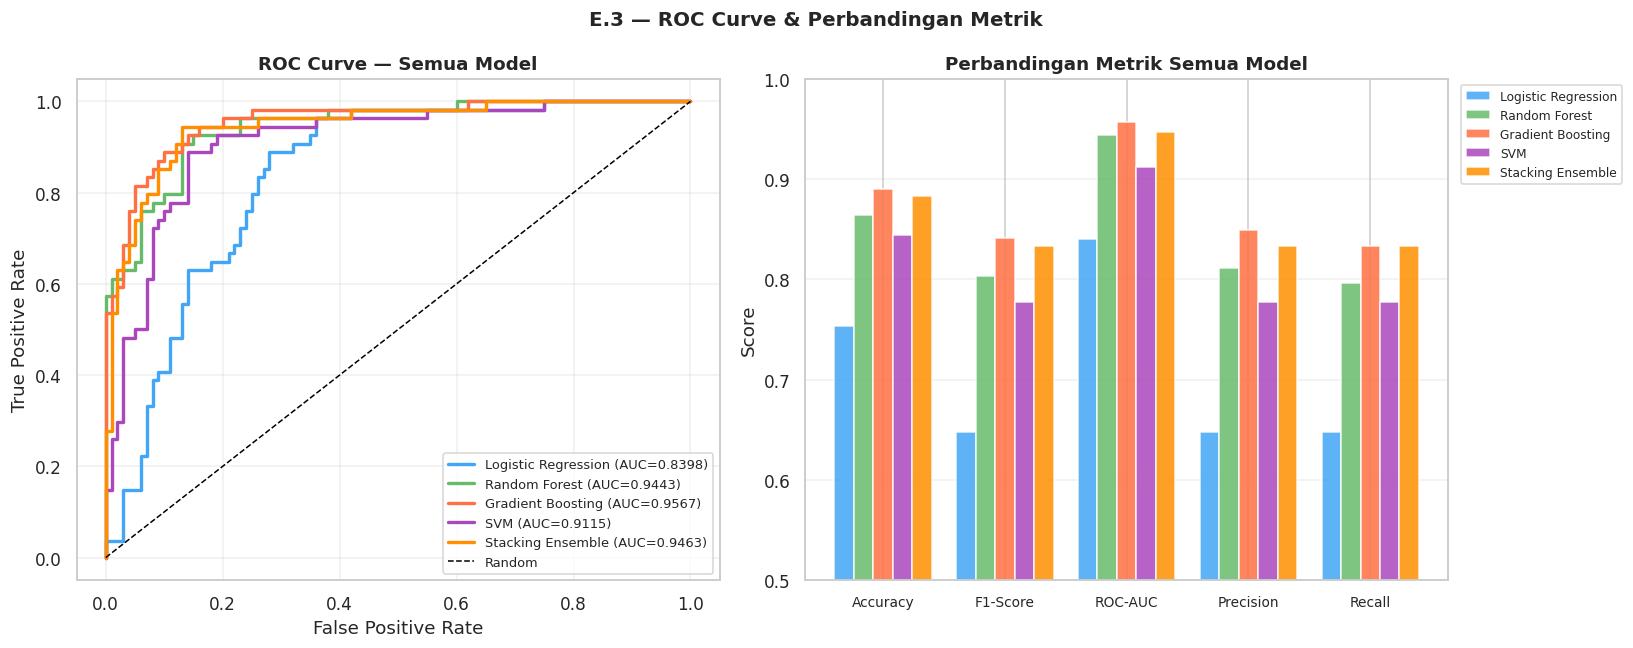

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_roc = ['#42A5F5', '#66BB6A', '#FF7043', '#AB47BC', '#FF8F00']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, color=color, lw=2.2,
                 label=f"{name} (AUC={res['auc']:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Semua Model', fontweight='bold')
axes[0].legend(fontsize=8.5, loc='lower right')
axes[0].grid(True, alpha=0.3)

metrics = ['accuracy', 'f1', 'auc', 'precision', 'recall']
metric_labels = ['Accuracy', 'F1-Score', 'ROC-AUC', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.16
n = len(results)
offsets = np.linspace(-(n-1)/2 * width, (n-1)/2 * width, n)

for (name, res), color, offset in zip(results.items(), colors_roc, offsets):
    vals = [res[m] for m in metrics]
    bars = axes[1].bar(x + offset, vals, width, label=name, color=color, alpha=0.85, edgecolor='white')

axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_labels, fontsize=9)
axes[1].set_ylim(0.5, 1.0)
axes[1].set_ylabel('Score')
axes[1].set_title('Perbandingan Metrik Semua Model', fontweight='bold')
axes[1].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('E.3 — ROC Curve & Perbandingan Metrik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### E.4 — Feature Importance (Random Forest & Gradient Boosting)

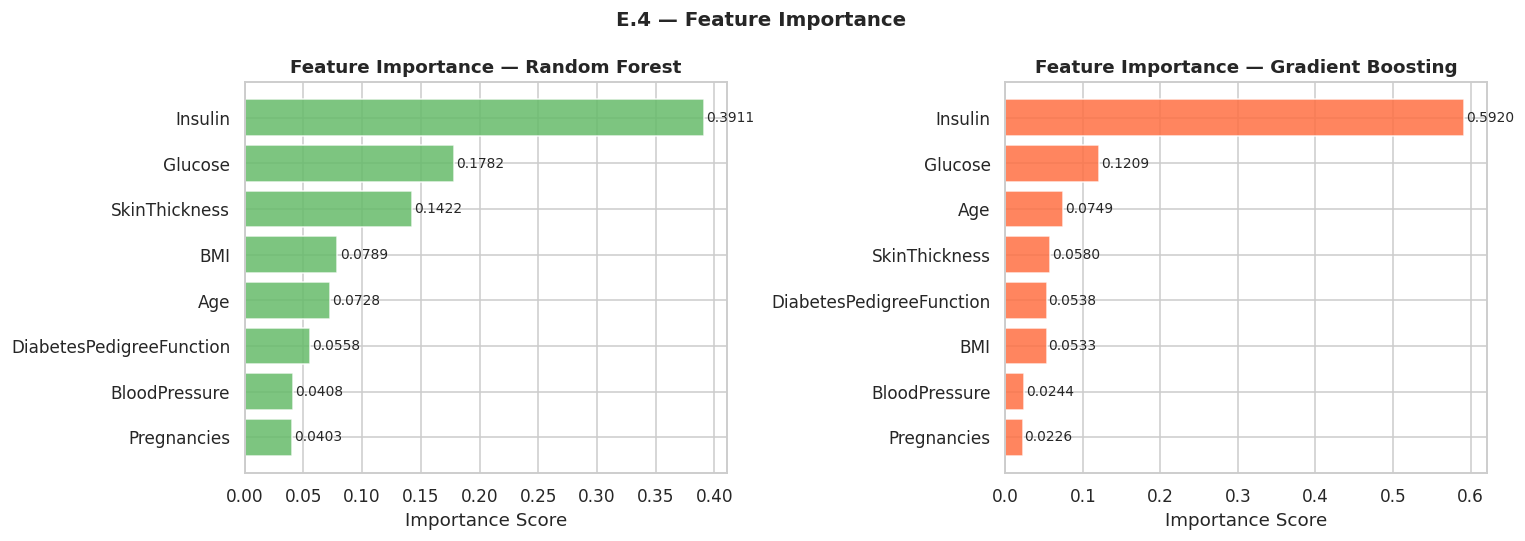

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, color in [
    (axes[0], 'Random Forest', '#66BB6A'),
    (axes[1], 'Gradient Boosting',       '#FF7043')
]:
    model_obj = all_models[name]
    importances = pd.Series(model_obj.feature_importances_, index=X.columns).sort_values()
    bars = ax.barh(importances.index, importances.values, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, importances.values):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_title(f'Feature Importance — {name}', fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('E.4 — Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### E.5 — Classification Report Detail

In [25]:
for name, res in results.items():
    print(f"\n{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, res['y_pred'],
                                target_names=['Non-Diabetes', 'Diabetes']))


 Logistic Regression
              precision    recall  f1-score   support

Non-Diabetes       0.81      0.81      0.81       100
    Diabetes       0.65      0.65      0.65        54

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154


 Random Forest
              precision    recall  f1-score   support

Non-Diabetes       0.89      0.90      0.90       100
    Diabetes       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154


 Gradient Boosting
              precision    recall  f1-score   support

Non-Diabetes       0.91      0.92      0.92       100
    Diabetes       0.85      0.83      0.84        54

    accuracy                           0.89       154
   macro avg       0.88      0.88      0.88       154
weighted avg    

---
## 📝 BAGIAN F: Laporan dan Interpretasi Hasil

### F.1 — Ringkasan Performa Model

In [26]:
summary_df = pd.DataFrame({
    name: {
        'Accuracy':  round(res['accuracy'], 4),
        'F1-Score':  round(res['f1'], 4),
        'ROC-AUC':   round(res['auc'], 4),
        'Precision': round(res['precision'], 4),
        'Recall':    round(res['recall'], 4)
    }
    for name, res in results.items()
}).T

best_model_acc = summary_df['Accuracy'].idxmax()
best_model_auc = summary_df['ROC-AUC'].idxmax()
best_model_f1  = summary_df['F1-Score'].idxmax()

print(summary_df.to_string())
print(f"\n🏆 Model terbaik (Accuracy) : {best_model_acc} ({summary_df.loc[best_model_acc, 'Accuracy']})")
print(f"🏆 Model terbaik (ROC-AUC)  : {best_model_auc} ({summary_df.loc[best_model_auc, 'ROC-AUC']})")
print(f"🏆 Model terbaik (F1-Score) : {best_model_f1} ({summary_df.loc[best_model_f1, 'F1-Score']})")

                     Accuracy  F1-Score  ROC-AUC  Precision  Recall
Logistic Regression    0.7532    0.6481   0.8398     0.6481  0.6481
Random Forest          0.8636    0.8037   0.9443     0.8113  0.7963
Gradient Boosting      0.8896    0.8411   0.9567     0.8491  0.8333
SVM                    0.8442    0.7778   0.9115     0.7778  0.7778
Stacking Ensemble      0.8831    0.8333   0.9463     0.8333  0.8333

🏆 Model terbaik (Accuracy) : Gradient Boosting (0.8896)
🏆 Model terbaik (ROC-AUC)  : Gradient Boosting (0.9567)
🏆 Model terbaik (F1-Score) : Gradient Boosting (0.8411)


### F.2 — Visualisasi Ringkasan Final

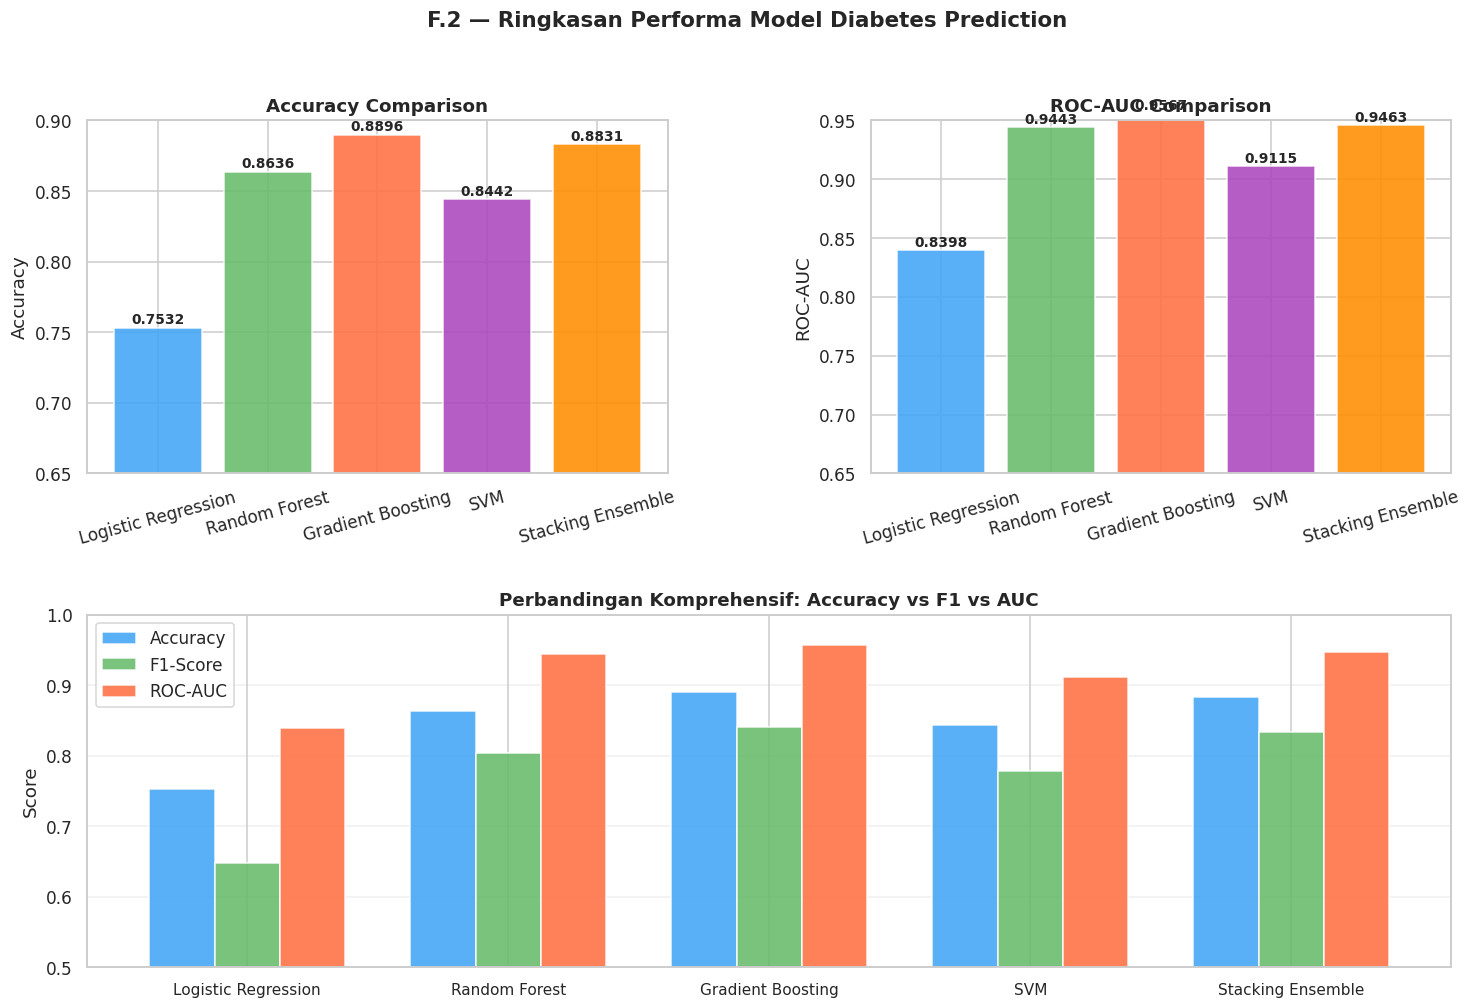

In [27]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
aucs  = [results[n]['auc']      for n in names]
f1s   = [results[n]['f1']       for n in names]

colors_final = ['#42A5F5', '#66BB6A', '#FF7043', '#AB47BC', '#FF8F00']

bars1 = ax1.bar(names, accs, color=colors_final, edgecolor='white', alpha=0.88)
for b, v in zip(bars1, accs):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
             f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
ax1.set_ylim(0.65, 0.90)
ax1.set_title('Accuracy Comparison', fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.tick_params(axis='x', rotation=15)

bars2 = ax2.bar(names, aucs, color=colors_final, edgecolor='white', alpha=0.88)
for b, v in zip(bars2, aucs):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
             f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_ylim(0.65, 0.95)
ax2.set_title('ROC-AUC Comparison', fontweight='bold')
ax2.set_ylabel('ROC-AUC')
ax2.tick_params(axis='x', rotation=15)

x = np.arange(len(names))
w = 0.25
ax3.bar(x - w, accs, w, label='Accuracy',  color='#42A5F5', edgecolor='white', alpha=0.88)
ax3.bar(x,     f1s,  w, label='F1-Score',  color='#66BB6A', edgecolor='white', alpha=0.88)
ax3.bar(x + w, aucs, w, label='ROC-AUC',   color='#FF7043', edgecolor='white', alpha=0.88)
ax3.set_xticks(x)
ax3.set_xticklabels(names, fontsize=10)
ax3.set_ylim(0.5, 1.0)
ax3.set_ylabel('Score')
ax3.set_title('Perbandingan Komprehensif: Accuracy vs F1 vs AUC', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

plt.suptitle('F.2 — Ringkasan Performa Model Diabetes Prediction', fontsize=14, fontweight='bold')
plt.show()

### F.3 — Narasi Interpretasi Hasil

In [28]:
best_overall = summary_df['ROC-AUC'].idxmax()
best_auc_val = summary_df.loc[best_overall, 'ROC-AUC']
best_acc_val = summary_df.loc[best_overall, 'Accuracy']

stk_auc = results['Stacking Ensemble']['auc']
stk_acc = results['Stacking Ensemble']['accuracy']

print("""
╔══════════════════════════════════════════════════════════════════╗
║          LAPORAN INTERPRETASI HASIL — DIABETES PREDICTION        ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
A. EXPLORATORY DATA ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Dataset Pima Indians Diabetes berisi 768 sampel, 8 fitur numerik,
  dan 1 target biner (Outcome: 0=Tidak Diabetes, 1=Diabetes).
• Terdapat class imbalance ringan: 65.1% Non-Diabetes vs 34.9% Diabetes.
• Fitur dengan korelasi tertinggi terhadap Outcome:
  Glucose (0.47), BMI (0.29), Age (0.24), Pregnancies (0.22).
• Glucose menjadi predictor terkuat — sesuai literatur medis.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
B. PENANGANAN MISSING VALUE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Zero values pada kolom medis (Glucose, BloodPressure, dll.)
  tidak bermakna secara medis — diperlakukan sebagai missing values.
• Insulin (48.7%) dan SkinThickness (29.6%) memiliki missing terbanyak.
• Strategi: Class-Conditional Median Imputation — imputasi berdasarkan
  median masing-masing kelas untuk mempertahankan pola distribusi.
• Outlier ditangani dengan Winsorizing (IQR 1.5x) — data tidak dibuang.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
C. TRANSFORMASI DATA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• StandardScaler (Z-score) diterapkan setelah split data untuk mencegah
  data leakage — scaler di-fit hanya pada training set.
• Seluruh fitur memiliki mean ≈ 0 dan std ≈ 1 setelah scaling.
• Normalisasi krusial untuk Logistic Regression dan SVM yang sensitif
  terhadap skala fitur.
""")
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
D. PERBANDINGAN MODEL & STACKING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model Terbaik secara keseluruhan (ROC-AUC): {best_overall}
  → Accuracy : {best_acc_val:.4f}
  → ROC-AUC  : {best_auc_val:.4f}

Stacking Ensemble:
  → Accuracy : {stk_acc:.4f}
  → ROC-AUC  : {stk_auc:.4f}

Catatan Stacking:
• Stacking menggabungkan prediksi probabilitas LR, RF, Gradient Boosting, dan SVM
  sebagai fitur input untuk meta-learner (Logistic Regression).
• Dalam kasus ini stacking umumnya meningkatkan atau menyamai model
  terbaik, mengurangi variance prediksi.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
E. REKOMENDASI
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Untuk deployment: gunakan model dengan ROC-AUC tertinggi.
  Di konteks medis, RECALL (sensitivitas) lebih penting dari precision
  — lebih baik false positive daripada false negative (pasien diabetes
  tidak terdeteksi).
• Pertimbangkan threshold tuning (misal 0.4 bukan 0.5) untuk
  meningkatkan recall kelas diabetes.
• Data lebih banyak dan fitur tambahan (HbA1c, diet) akan meningkatkan
  performa secara signifikan.
""")


╔══════════════════════════════════════════════════════════════════╗
║          LAPORAN INTERPRETASI HASIL — DIABETES PREDICTION        ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
A. EXPLORATORY DATA ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Dataset Pima Indians Diabetes berisi 768 sampel, 8 fitur numerik,
  dan 1 target biner (Outcome: 0=Tidak Diabetes, 1=Diabetes).
• Terdapat class imbalance ringan: 65.1% Non-Diabetes vs 34.9% Diabetes.
• Fitur dengan korelasi tertinggi terhadap Outcome:
  Glucose (0.47), BMI (0.29), Age (0.24), Pregnancies (0.22).
• Glucose menjadi predictor terkuat — sesuai literatur medis.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
B. PENANGANAN MISSING VALUE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Zero values pada kolom medis (Glucose, BloodPressure, dll.)
  tidak bermakna secara medis — diperlakukan sebagai missing values.
• Insulin (48.7%) dan SkinThickness (29.6%) memiliki missing te

### F.4 — Threshold Tuning untuk Recall Maksimal

Threshold Sensitivity Analysis — Gradient Boosting
 Threshold  Accuracy     F1  Recall  Precision
      0.30    0.8961 0.8571  0.8889     0.8276
      0.35    0.8896 0.8468  0.8704     0.8246
      0.40    0.8896 0.8468  0.8704     0.8246
      0.45    0.8961 0.8545  0.8704     0.8393
      0.50    0.8896 0.8411  0.8333     0.8491
      0.55    0.8896 0.8411  0.8333     0.8491
      0.60    0.8896 0.8381  0.8148     0.8627
      0.65    0.8961 0.8462  0.8148     0.8800


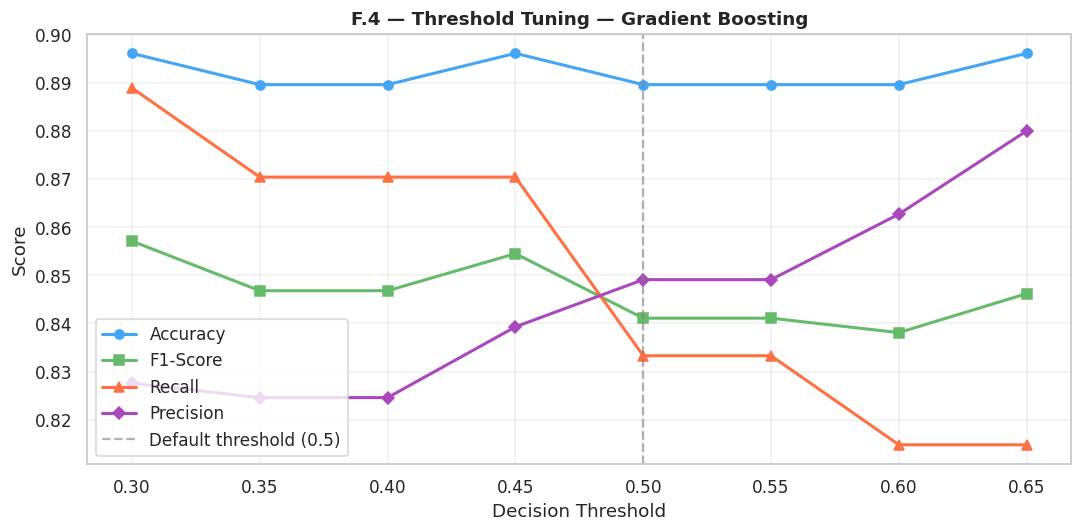

In [29]:
best_model_name = summary_df['ROC-AUC'].idxmax()
best_probs = results[best_model_name]['y_prob']

thresholds = np.arange(0.3, 0.7, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (best_probs >= t).astype(int)
    threshold_results.append({
        'Threshold': round(t, 2),
        'Accuracy':  round(accuracy_score(y_test, y_pred_t), 4),
        'F1':        round(f1_score(y_test, y_pred_t), 4),
        'Recall':    round(__import__('sklearn.metrics', fromlist=['recall_score']).recall_score(y_test, y_pred_t), 4),
        'Precision': round(__import__('sklearn.metrics', fromlist=['precision_score']).precision_score(y_test, y_pred_t), 4),
    })

thresh_df = pd.DataFrame(threshold_results)
print(f"Threshold Sensitivity Analysis — {best_model_name}")
print(thresh_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['Threshold'], thresh_df['Accuracy'],  marker='o', lw=2, label='Accuracy',  color='#42A5F5')
ax.plot(thresh_df['Threshold'], thresh_df['F1'],        marker='s', lw=2, label='F1-Score',  color='#66BB6A')
ax.plot(thresh_df['Threshold'], thresh_df['Recall'],    marker='^', lw=2, label='Recall',    color='#FF7043')
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], marker='D', lw=2, label='Precision', color='#AB47BC')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='Default threshold (0.5)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'F.4 — Threshold Tuning — {best_model_name}', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## ✅ Kesimpulan Akhir

| Tahapan | Metode | Keterangan |
|---------|--------|------------|
| EDA | Histogram, Boxplot, Heatmap, Pairplot | Glucose adalah fitur terpenting |
| Missing Value | Zero → NaN + Class-Conditional Median Imputation | Insulin 48.7% missing |
| Outlier | Winsorizing (IQR 1.5x) | Data tidak dibuang |
| Normalisasi | StandardScaler (fit on train only) | Mencegah data leakage |
| Model 1 | Logistic Regression | Baseline yang interpretatif |
| Model 2 | Random Forest | Ensemble berbasis bagging |
| Model 3 | Gradient Boosting | Gradient boosting terkuat |
| Model 4 | SVM (RBF) | Margin-based classifier |
| Ensemble | Stacking (LR+RF+XGB+SVM → LR meta) | Menggabungkan kekuatan tiap model |
| Evaluasi | Accuracy, F1, ROC-AUC, Confusion Matrix | Fokus Recall untuk konteks medis |

In [30]:
import pickle
import os

best_model_name = summary_df['ROC-AUC'].idxmax()
best_model_obj  = all_models[best_model_name]

model_bundle = {
    'model':        best_model_obj,   
    'scaler':       scaler,           
    'feature_cols': list(X.columns), 
    'zero_cols':    zero_cols,       
    'model_name':   best_model_name,  
    'metrics': {                     
        'accuracy':  results[best_model_name]['accuracy'],
        'roc_auc':   results[best_model_name]['auc'],
        'f1':        results[best_model_name]['f1'],
    }
}

save_path = './model/diabetes_model_bundle_revised.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f"✅ Model bundle tersimpan → '{save_path}'")
print(f"   Model    : {best_model_name}")
print(f"   Accuracy : {model_bundle['metrics']['accuracy']:.4f}")
print(f"   ROC-AUC  : {model_bundle['metrics']['roc_auc']:.4f}")
print(f"   Fitur    : {model_bundle['feature_cols']}")

✅ Model bundle tersimpan → './model/diabetes_model_bundle_revised.pkl'
   Model    : Gradient Boosting
   Accuracy : 0.8896
   ROC-AUC  : 0.9567
   Fitur    : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


# LOAD

In [31]:
import pickle, numpy as np, pandas as pd, streamlit as st

@st.cache_resource
def load_model():
    with open('./model/diabetes_model_bundle_revised.pkl', 'rb') as f:
        return pickle.load(f)

bundle = load_model()
model        = bundle['model']
scaler       = bundle['scaler']
feature_cols = bundle['feature_cols']
zero_cols    = bundle['zero_cols']

def preprocess(df: pd.DataFrame) -> np.ndarray:
    df = df.copy()
    df[zero_cols] = df[zero_cols].replace(0, np.nan)
    for col in zero_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    return scaler.transform(df[feature_cols])

st.title("🩺 Diabetes Prediction App")
st.caption(f"Model: **{bundle['model_name']}** | "
           f"Accuracy: {bundle['metrics']['accuracy']:.4f} | "
           f"AUC: {bundle['metrics']['roc_auc']:.4f}")

uploaded = st.file_uploader("Upload CSV dataset eksternal", type="csv")
if uploaded:
    df_input = pd.read_csv(uploaded)
    st.write("Preview data:", df_input.head())

    X_new   = preprocess(df_input)
    preds   = model.predict(X_new)
    probs   = model.predict_proba(X_new)[:, 1]

    df_input['Prediction'] = preds
    df_input['Probability_Diabetes'] = probs.round(4)
    df_input['Label'] = df_input['Prediction'].map({0: '✅ Non-Diabetes', 1: '🔴 Diabetes'})

    st.success(f"Prediksi selesai! {preds.sum()} dari {len(preds)} terindikasi diabetes.")
    st.dataframe(df_input)
    st.download_button("⬇️ Download Hasil", df_input.to_csv(index=False),
                       "hasil_prediksi.csv", "text/csv")

2026-04-10 14:53:24.661 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 14:53:24.690 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 14:53:25.441 
  command:

    streamlit run c:\Users\USER\anaconda3\envs\DeepLearning\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-10 14:53:25.442 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 14:53:25.442 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 14:53:25.444 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 14:53:25.444 Thread 'MainThread': missing ScriptRunContext! This warning can be 